In [25]:
from astropy.time import Time
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.dates import date2num
import numpy as np
import matplotlib.patches as patches
from datetime import datetime

In [26]:
# Julian dates stored in text files must have this bias added to them when they
# are converted to conventional julian dates (eg, with AstroPy).
JULDATE_BIAS = 2440000.0

def read_obs_pred_file(pred_file, no_date_parse=False, no_juldate_bias=False):
    """Return parsed obs or pred file.

    Args
       pred_file: Path to pred file
       no_date_parse: (optional) set to true to disable parsing dates,
         which is much faster.
    Returns
       Pandas data frame with the juldate column replaced with datetime
       instances.
    """
    if no_juldate_bias:
        juldate_offset = 0
    else:
        juldate_offset = JULDATE_BIAS

    df = pd.read_csv(pred_file, sep='\\s+', comment='#')

    if not no_date_parse:
        df['juldate'] = [
            Time(float(s) + juldate_offset, format='jd').to_datetime()
            for s in df['juldate']
        ]
    
    return df

In [27]:
def read_locs_file(locs_file):
    locs_df = pd.read_csv(
          locs_file, delim_whitespace=True,
          names=['sat_time_jd', 'sat_lon', 'carrot_num', 'sat_lat', 'radii']
    )
 
    locs_df['juldate'] = Time(locs_df.sat_time_jd, format='jd').to_datetime()

    return locs_df

# Load Data

In [28]:
df_pred_stereo = read_obs_pred_file('wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/field_line_03_R000_gongz_stereoa.dat')
df_pred_earth = read_obs_pred_file('wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/field_line_03_R000_gongz_earth.dat')

In [29]:
df_pred_stereo.juldate.min()

Timestamp('2007-01-03 16:40:22.079989')

In [30]:
df_pred_stereo.juldate.max()

Timestamp('2026-01-03 11:16:56.640003')

In [31]:
df_obs_stereo = read_obs_pred_file('wsa-v7/WSA_DATA/DATA/SATELLITES/STEREOA/stereoA_L2_hr.dat')
df_obs_earth = read_obs_pred_file('wsa-v7/WSA_DATA/DATA/SATELLITES/ACEL2/acel2_hr.dat')

In [32]:
df_locs_stereo = read_locs_file('wsa-v7/WSA_DATA/DATA/SATELLITES/STEREOA/stereoA_locs.dat')
df_locs_earth = read_locs_file('wsa-v7/WSA_DATA/DATA/SATELLITES/ACE/Ace_locs.dat')

/home/dedasilv/.micromamba/envs/WSA-v7/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 4019 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/dedasilv/.micromamba/envs/WSA-v7/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 7670 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [33]:
df_locs_stereo

,sat_time_jd,sat_lon,carrot_num,sat_lat,radii,juldate
0,2454035.5,248.559466,2049.309557,4.870339,0.992692,2006-10-27
1,2454036.5,235.374313,2049.346182,4.778076,0.991757,2006-10-28
2,2454037.5,222.188236,2049.382810,4.685918,0.991063,2006-10-29
3,2454038.5,209.001832,2049.419439,4.592887,0.990528,2006-10-30
4,2454039.5,195.815097,2049.456069,4.498720,0.990122,2006-10-31
...,...,...,...,...,...,...
12115,2466150.5,189.530475,2493.473526,-2.941054,0.967292,2039-12-28
12116,2466151.5,176.372889,2493.510075,-3.061640,0.967315,2039-12-29
12117,2466152.5,163.215485,2493.546624,-3.181238,0.967337,2039-12-30
12118,2466153.5,150.058275,2493.583171,-3.299812,0.967356,2039-12-31


In [86]:
df_metric_stereo = read_obs_pred_file(
    'wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/parcel_03_R000_gongz_stereoa_stereoa.dat',
    no_juldate_bias=True
)

In [87]:
df_metric_stereo

,juldate,month,day,year,doy,Vp,imf,curr_sheet_dist,map_age,B_footpoint,...,coronal_hole_dist,B_subsat,expansion_factor,squashing_factor,parcel_depart_time,output_file,day3,day7,day14,day27
0,2007-01-03 16:40:22.079989,1,3,2007,3,661.6,1.0,18.1,0,2.4286,...,7.1981,1084.4716,8.7746,0.4958,14101.7035,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
1,2007-01-03 18:19:52.319986,1,3,2007,3,684.2,1.0,18.1,0,1.7766,...,7.0610,1083.9294,6.5161,0.5247,14101.8551,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
2,2007-01-03 21:22:53.760000,1,3,2007,3,691.2,1.0,18.1,0,1.5940,...,6.7344,1086.2489,5.9496,0.6631,14102.0066,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
3,2007-01-04 02:51:47.519992,1,4,2007,4,669.6,1.0,18.2,0,2.0714,...,6.4237,1091.1073,7.8845,0.7563,14102.1581,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
4,2007-01-04 07:54:37.439985,1,4,2007,4,654.0,1.0,18.1,0,2.4947,...,6.4057,1097.7700,9.7044,0.6636,14102.3097,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45569,2026-01-03 09:39:27.360002,1,3,2026,3,376.4,1.0,7.5,0,7.0327,...,1.7652,2363.2634,10.9199,1.0858,21039.5664,wsa_202512310114R000_gongz.fits,3.5637,1.5841,1.6804,1.9303
45570,2026-01-03 09:39:35.999987,1,3,2026,3,376.4,1.0,6.0,0,5.5602,...,2.4272,2391.7297,9.7222,1.1397,21039.7180,wsa_202512310114R000_gongz.fits,3.5637,1.5841,1.6804,1.9303
45571,2026-01-03 09:39:44.640013,1,3,2026,3,376.4,1.0,4.7,0,5.8997,...,2.9299,2415.3245,12.4391,1.0473,21039.8695,wsa_202512310114R000_gongz.fits,-999.9999,1.4872,1.4047,1.7052
45572,2026-01-03 09:39:53.279998,1,3,2026,3,376.4,1.0,3.2,0,5.3758,...,2.9054,2432.5000,14.9007,1.5441,21040.0210,wsa_202512310114R000_gongz.fits,3.5637,1.5841,1.6804,1.9303


In [88]:
df_metric_earth = read_obs_pred_file(
    'wsa-v7/wsa/WSA_WORKING/DefaultGroup/Mars_L1_Stereo_Analysis/PREDSOLARWIND/parcel_03_R000_gongz_earth_ace.dat',
    no_juldate_bias=True
)
df_metric_earth

,juldate,month,day,year,doy,Vp,imf,curr_sheet_dist,map_age,B_footpoint,...,coronal_hole_dist,B_subsat,expansion_factor,squashing_factor,parcel_depart_time,output_file,day3,day7,day14,day27
0,2007-01-03 17:02:49.919993,1,3,2007,3,663.3,1.0,18.0,0,2.3654,...,7.1724,1107.3678,8.5793,0.4932,14101.7035,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
1,2007-01-03 18:52:59.519990,1,3,2007,3,683.7,1.0,18.0,0,1.7733,...,6.9944,1106.9379,6.5569,0.5138,14101.8551,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
2,2007-01-03 22:03:38.879990,1,3,2007,3,689.2,1.0,18.0,0,1.6279,...,6.6858,1106.4094,6.1108,0.6698,14102.0066,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
3,2007-01-04 04:06:23.039993,1,4,2007,4,661.6,1.0,18.1,0,2.2943,...,6.4976,1105.7867,8.7656,0.7686,14102.1581,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
4,2007-01-04 08:16:22.079981,1,4,2007,4,655.9,1.0,17.9,0,2.4136,...,6.3474,1105.0747,9.4643,0.6547,14102.3097,wsa_200701010304R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44136,2026-01-02 23:04:24.959992,1,2,2026,2,335.5,-1.0,21.6,0,-3.4965,...,1.3175,-2231.2803,3.2895,-2.4196,21038.5057,wsa_202512310114R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
44137,2026-01-02 23:04:33.600018,1,2,2026,2,335.5,-1.0,22.7,0,-52.8410,...,1.8462,-2233.9443,49.0450,-2.4466,21038.6573,wsa_202512310114R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
44138,2026-01-02 23:04:42.240003,1,2,2026,2,335.5,-1.0,23.6,0,-56.0679,...,2.3683,-2237.1482,51.6587,-0.7922,21038.8088,wsa_202512310114R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999
44139,2026-01-02 23:04:50.879989,1,2,2026,2,335.5,-1.0,24.7,0,-51.9617,...,2.1537,-2240.9160,47.4704,-1.1677,21038.9603,wsa_202512310114R000_gongz.fits,-999.9999,-999.9999,-999.9999,-999.9999


## Look at Data Availability

(array([4452., 4517., 4422., 4546., 4550., 4367., 4787., 4718., 4618.,
        4599.]),
 array([13516.6947 , 14210.67224, 14904.64978, 15598.62732, 16292.60486,
        16986.5824 , 17680.55994, 18374.53748, 19068.51502, 19762.49256,
        20456.4701 ]),
 <BarContainer object of 10 artists>)

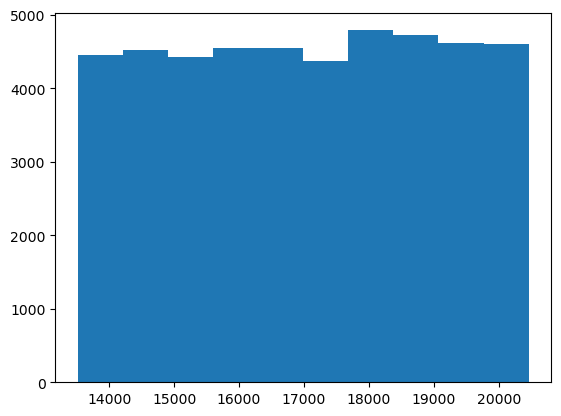

In [37]:
plt.hist(date2num(df_pred_stereo.juldate))

(array([4465., 4270., 4375., 4514., 4197., 4470., 4471., 4486., 4493.,
        4402.]),
 array([13516.7103 , 14210.63545, 14904.5606 , 15598.48575, 16292.4109 ,
        16986.33605, 17680.2612 , 18374.18635, 19068.1115 , 19762.03665,
        20455.9618 ]),
 <BarContainer object of 10 artists>)

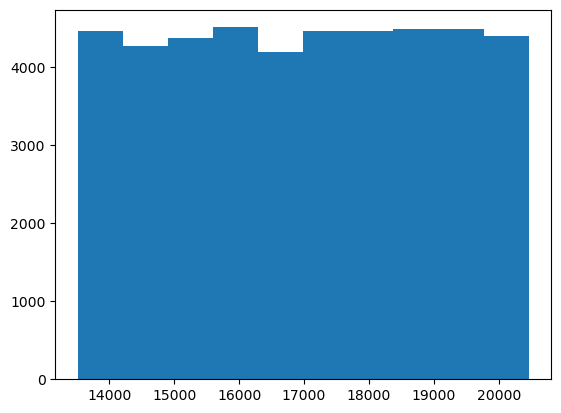

In [38]:
plt.hist(date2num(df_pred_earth.juldate))

(array([16712., 16671., 16674., 16677., 16885., 16679., 16789., 16662.,
        16656., 16658.]),
 array([13514.   , 14207.996, 14901.992, 15595.988, 16289.984, 16983.98 ,
        17677.976, 18371.972, 19065.968, 19759.964, 20453.96 ]),
 <BarContainer object of 10 artists>)

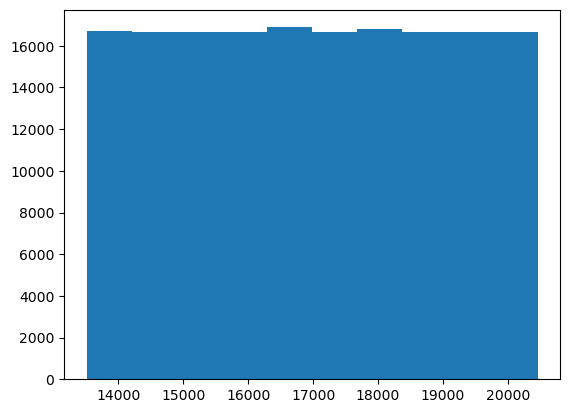

In [39]:
plt.hist(date2num(df_obs_stereo.juldate))

(array([12732., 12732., 12732., 12732., 12732., 12732., 12732., 12732.,
        12732., 12732.]),
 array([14610.   , 15140.496, 15670.992, 16201.488, 16731.984, 17262.48 ,
        17792.976, 18323.472, 18853.968, 19384.464, 19914.96 ]),
 <BarContainer object of 10 artists>)

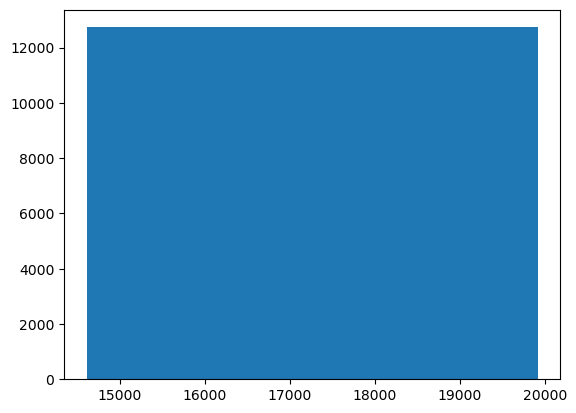

In [40]:
plt.hist(date2num(df_obs_earth.juldate))

# Remove CME's from stereo

In [41]:
def parse_space_date(date_str):
    # Split the string from the right on the first space 
    # e.g., "2011 7/23 9:41" -> date_part="2011 7/23", time_part="9:41"
    
    # Check if there is a decimal point in the time
    if '.' in date_str:
        date_part, time_part = date_str.rsplit(' ', 1)

        # Split into the whole minutes and the decimal fraction
        time_base, time_fraction = time_part.split('.')
        
        # Parse the base date (e.g., "2011 7/23 9:41")
        base_time_str = f"{date_part} {time_base}"
        base_dt = pd.to_datetime(base_time_str, format='%Y %m/%d %H:%M')
        
        # Calculate the extra seconds 
        # Note: We multiply by 60 assuming these are fractional minutes.
        # (If they are actually fractions of a second, just change `* 60` to `* 1`)
        extra_seconds = float(f"0.{time_fraction}") * 60 
        
        return base_dt + pd.Timedelta(seconds=extra_seconds)
    
    else:
        # No decimal present, just parse the whole string directly
        return pd.to_datetime(date_str, format='%Y %m/%d %H:%M')


## Remove CMEs in STEREO

In [42]:
df_stereo_cme = df = pd.read_excel('STEREO_Level3_ICME.xlsx', skiprows=8) 
df_stereo_cme = df_stereo_cme[~pd.isna(df_stereo_cme['STEREO']) ]
df_stereo_cme.columns

Index(['#', 'STEREO', 'Start time [Year Month/Day HH:MM] ',
       'Magnetic obstacle (~ flux rope) start time1', 'End time',
       'Ptmax [pPa]', 'Bmax [nT]', 'Vmax [km/s]', '∆V2 [km/s]', 'Group3',
       'MC (2 for better defined)', 'Comment'],
      dtype='object')

In [43]:
for _, row in df_stereo_cme.iterrows():
    if 'A' in row['STEREO']:
        stime_str = row['Start time [Year Month/Day HH:MM] ']
        try:
            stime = parse_space_date(stime_str)
        except Exception as e:
            print(stime_str)
            continue
        etime = parse_space_date(row['End time'])
        df_obs_stereo.loc[(df_obs_stereo.juldate > stime) & (df_obs_stereo.juldate < etime), 'Vp_obs'] = np.nan

2013 2:45.725
2023 02/20 00:39 
2024/11/20 07:56
2025/05/30 09:37


## Remove CMEs in Earth

In [44]:
# Remove CME events from ace_aligned using icmetable2.xlsx
icme = pd.read_excel(r'./icmetable2.xlsx')

for i in range(len(icme)):
    stime = pd.to_datetime(str(icme.iloc[i, 0]).split('(')[0].strip())
    etime = pd.to_datetime(str(icme.iloc[i, 2]).split('(')[0].strip())
    df_obs_earth.loc[(df_obs_earth.juldate > stime) & (df_obs_earth.juldate < etime), 'Vp_obs'] = np.nan


# Plot all data

In [45]:
df_obs_stereo.loc[df_obs_stereo.Vp_obs < 200, 'Vp_obs'] = np.nan

Text(0, 0.5, 'km/s')

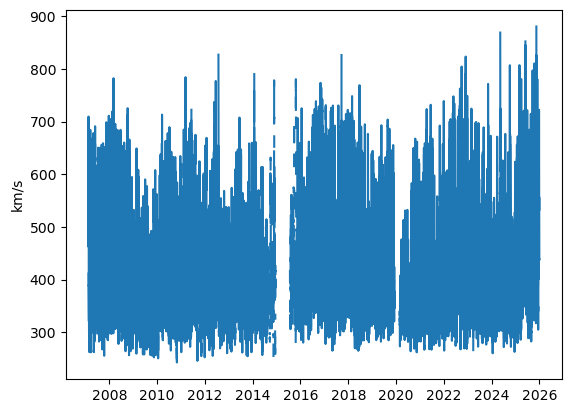

In [46]:
plt.plot(df_obs_stereo.juldate, df_obs_stereo.Vp_obs)
plt.ylabel('km/s')

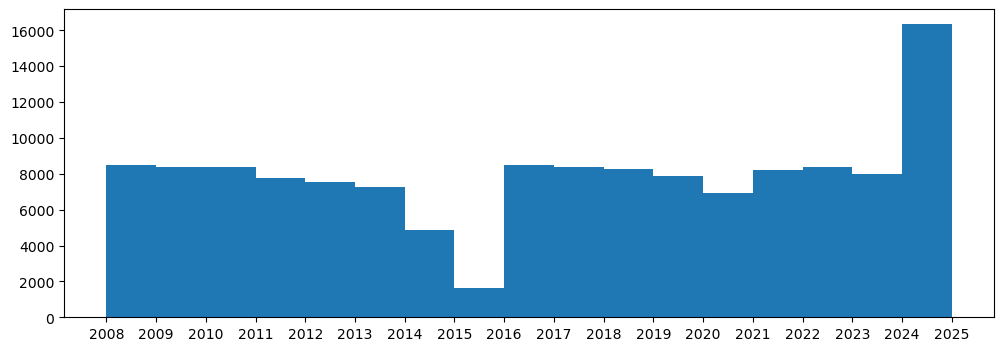

In [47]:
plt.figure(figsize=(12, 4))
plt.hist([row.year for _, row in df_obs_stereo.iterrows() if not pd.isna(row.Vp_obs)], bins=np.arange(2008, 2026))
plt.xticks(np.arange(2008, 2026))
None

(16071.0, 17166.0)

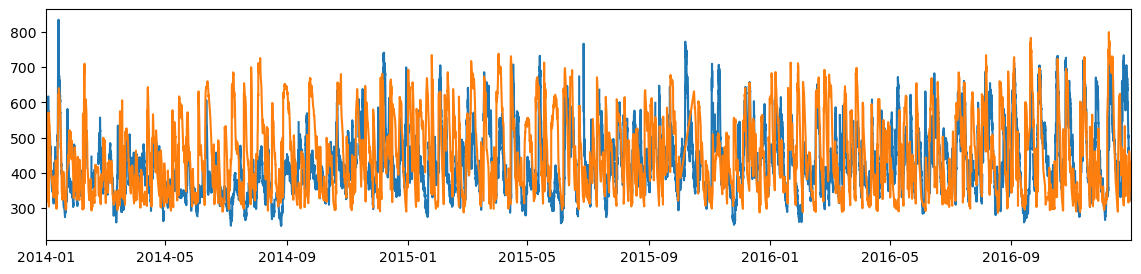

In [48]:

plt.figure(figsize=(14, 3))
plt.plot(df_obs_earth.juldate, df_obs_earth.Vp_obs)
plt.plot(df_pred_earth.juldate, df_pred_earth.Vp)

plt.xlim(datetime(2014, 1, 1), datetime(2016, 12, 31))

## Investigate NaN's

In [49]:
mask = np.isfinite(df_obs_earth.Vp_obs)
mask.sum() / mask.size

0.9219839773798304

In [50]:
mask = np.isfinite(df_obs_stereo.Vp_obs)
mask.sum() / mask.size

0.854288501942381

## Align Predictions and Observational Data

In [51]:
df_pred_stereo_tmp = (
    df_pred_stereo[['juldate', 'Vp']]
    .set_index('juldate')
    .resample('4h')
    .mean()
    .reset_index()
)
df_final_stereo = pd.merge_asof(
    df_obs_stereo, 
    df_pred_stereo_tmp, 
    on='juldate', 
    direction='nearest'
)


df_pred_earth_tmp = (
    df_pred_earth[['juldate', 'Vp']]
    .set_index('juldate')
    .resample('4h')
    .mean()
    .reset_index()
)
df_final_earth = pd.merge_asof(
    df_obs_earth, 
    df_pred_earth_tmp, 
    on='juldate', 
    direction='nearest'
)

# Plot by Year

In [52]:
def plot_by_year(df, label):
    yearmin = df.juldate.min().year
    yearmax = df.juldate.max().year

    d = {}

    for year in range(2010, yearmax + 1):
        mask = np.array([d.year == year for d in df.juldate])

        print(year, mask.sum())
    
        #if mask.sum() < 5000:
        #    d[year] = np.nan
        #    continue
            
        #d[year] = np.sqrt(np.nanmean(np.square(df[mask].Vp_obs - df[mask].Vp)))
        df_cur = df[mask]
        if df_cur.empty:
            d[year] = np.nan
        else:
            key = 'day27'
            df_cur = df_cur[df_cur[key] > 0]
            d[year] = df_cur[key].mean()
            
    plt.plot(d.keys(), d.values(), label=label)

2010 2470
2011 2307
2012 2336
2013 2399
2014 2429
2015 2281
2016 2345
2017 2308
2018 2474
2019 2561
2020 2648
2021 2379
2022 2356
2023 2442
2024 2427
2025 2429
2026 10
2010 2302
2011 2254
2012 2389
2013 2246
2014 2514
2015 2152
2016 2215
2017 2382
2018 2325
2019 2333
2020 2475
2021 2311
2022 2259
2023 2468
2024 2271
2025 2355
2026 10


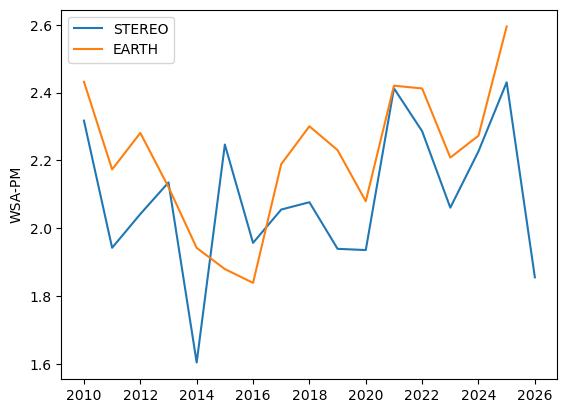

In [53]:
#plot_by_year(df_final_stereo, 'STEREO')
#plot_by_year(df_final_earth, 'EARTH')
#plt.ylabel('RMSE (km/s)')
#plt.legend()

plot_by_year(df_metric_stereo, 'STEREO')
plot_by_year(df_metric_earth, 'EARTH')
plt.ylabel('WSA-PM')
plt.legend()

In [54]:
df_final_stereo.size / df_final_earth.size

1.3121504869619856

# Compute by Angular Separations

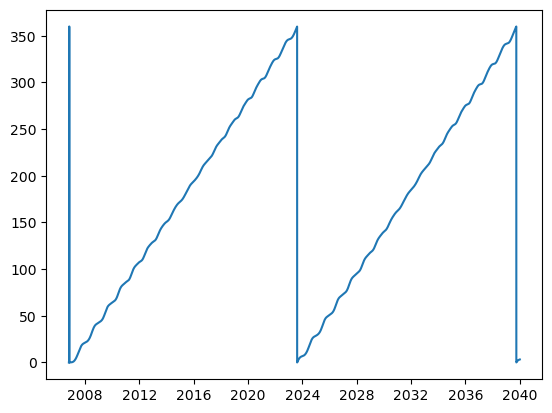

In [55]:
df_locs = df_locs_stereo.merge(df_locs_earth, on='sat_time_jd', suffixes=('_stereo', '_earth'))

# daily separations, then circular mean (don't average longitudes first)
delta = (df_locs['sat_lon_stereo'] - df_locs['sat_lon_earth']) % 360
df_locs['sep'] = np.rad2deg(np.angle(np.exp(1j * np.deg2rad(delta)))) % 360

plt.plot(df_locs.juldate_earth, df_locs['sep'])

In [90]:
 df_metric_stereo['stereo_angle'] = np.interp(date2num(df_metric_stereo.juldate), 
                                             date2num(df_locs.juldate_stereo),
                                             np.unwrap(df_locs.sep)) % 360

/tmp/ipykernel_1461692/3606768237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_metric_stereo['stereo_angle'] = np.interp(date2num(df_metric_stereo.juldate),


In [91]:
df_metric_earth['stereo_angle'] = np.interp(date2num(df_metric_earth.juldate),
                                           date2num(df_locs.juldate_stereo),
                                           np.unwrap(df_locs.sep)) % 360

/tmp/ipykernel_1461692/2539651924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_metric_earth['stereo_angle'] = np.interp(date2num(df_metric_earth.juldate),


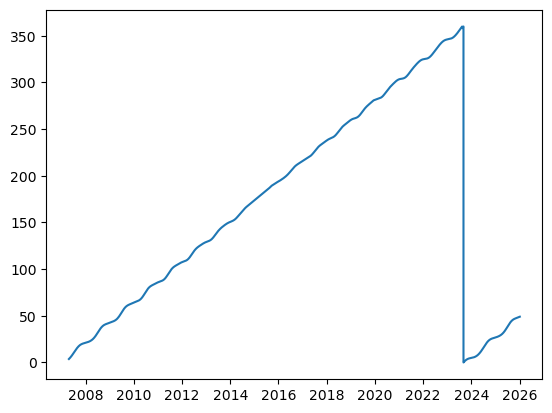

In [92]:
plt.plot(df_metric_stereo.juldate, df_metric_stereo.stereo_angle)

In [93]:
df_metric_earth['stereo_angle'].describe()

count    35184.000000
mean       175.165248
std        105.315425
min          0.011550
25%         87.432319
50%        171.001517
75%        268.193693
max        359.996311
Name: stereo_angle, dtype: float64

In [94]:
regions = [((i * np.pi / 2) + np.pi/4, ((i + 1) * np.pi / 2) + np.pi/4) for i in range(4)]

for i, region in enumerate(regions):
    print(f"Quadrant {i}: {region[0]:.3f} to {region[1]:.3f} radians")

Quadrant 0: 0.785 to 2.356 radians
Quadrant 1: 2.356 to 3.927 radians
Quadrant 2: 3.927 to 5.498 radians
Quadrant 3: 5.498 to 7.069 radians


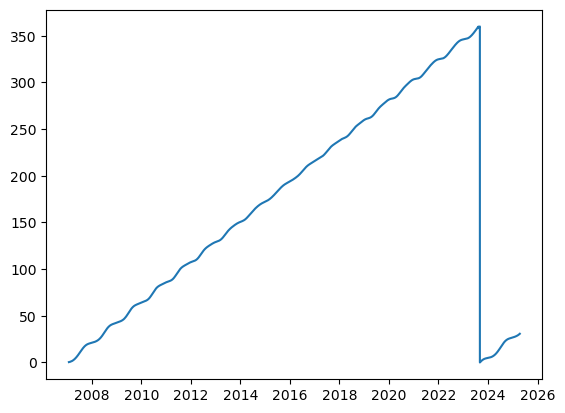

In [95]:
plt.plot(df_metric_earth.juldate, df_metric_earth.stereo_angle)

In [96]:
def format_year_ranges(years):
    # Handle empty lists
    if not years:
        return ""

    # Sort the list and remove any duplicates
    sorted_years = sorted(set(years))
    
    ranges = []
    start = sorted_years[0]
    end = sorted_years[0]

    for year in sorted_years[1:]:
        if year == end + 1:
            # The year is consecutive; extend the current range
            end = year
        else:
            # The year is not consecutive; save the previous range
            if start == end:
                ranges.append(str(start))
            else:
                ranges.append(f"{start}-{end}")
            
            # Start a new range
            start = year
            end = year

    # Don't forget to append the final range after the loop finishes
    if start == end:
        ranges.append(str(start))
    else:
        ranges.append(f"{start}-{end}")

    # Join the ranges into a single string
    return ", ".join(ranges)


Text(0, 2.8, '\n\nEarth')

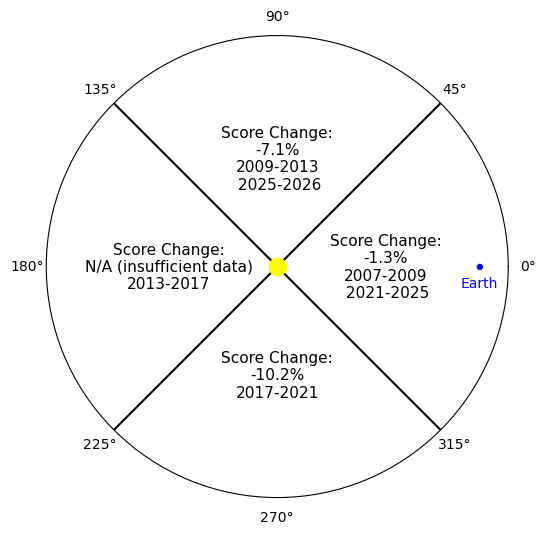

In [106]:
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
tmp = 0
errors = []

# ==========================================
# 1. MOVE STATIC FILTERING OUTSIDE THE LOOP
# ==========================================
# Filter dates (removing 2015-2016)
#date_mask_stereo = ~((df_metric_stereo.juldate > datetime(2014, 1, 1)) & (df_metric_stereo.juldate < datetime(2016, 12, 31)))
#df_metric_stereo = df_metric_stereo[date_mask_stereo]

#date_mask_earth = ~((df_metric_earth.juldate > datetime(2014, 1, 1)) & (df_metric_earth.juldate < datetime(2016, 12, 31)))
#df_metric_earth = df_metric_earth[date_mask_earth]

# Filter day27 > 0 
df_metric_stereo = df_metric_stereo[df_metric_stereo.day27 > 0]
df_metric_earth = df_metric_earth[df_metric_earth.day27 > 0]

# ==========================================
# 2. RUN THE LOOP ON PRE-FILTERED DATAFRAMES
# ==========================================
for i, (a, b) in enumerate(regions):
    a_deg = np.rad2deg(a)
    b_deg = np.rad2deg(b)
    
    # Create the regional masks using the pre-filtered DataFrames
    stereo_mask = (df_metric_stereo.stereo_angle > a_deg) & (df_metric_stereo.stereo_angle < b_deg)
    if b_deg > 360:
        stereo_mask |= (df_metric_stereo.stereo_angle < b_deg - 360)

    earth_mask = (df_metric_earth.stereo_angle > a_deg) & (df_metric_earth.stereo_angle < b_deg)
    if b_deg > 360:
        earth_mask |= (df_metric_earth.stereo_angle < b_deg - 360)
    
    # NOTE: Assuming `mask` is a globally defined boolean series, ensure its index 
    # perfectly aligns with df_metric_stereo/earth to prevent another memory explosion.
    # We combine it with the regional masks to get the subset for THIS specific region:
    region_stereo = df_metric_stereo[stereo_mask]
    region_earth = df_metric_earth[earth_mask]
    
    err_stereo = region_stereo.day27.mean()
    err_earth = region_earth.day27.mean()

    # Handle division by zero just in case
    if err_earth and not np.isnan(err_earth) and err_earth != 0:
        rel_err = f'{100 * (err_stereo / err_earth - 1):.1f}%'
    else:
        rel_err = np.nan

    if i == 1:
        rel_err = 'N/A (insufficient data)'
    
    # Get the years specific to this region 
    stereo_years = sorted(set(region_stereo['juldate'].dt.year)) # Faster pandas way if juldate is datetime64
    year_labels = format_year_ranges(stereo_years).replace(",", "\n")
    # Plotting
    ax.text(np.deg2rad(a_deg + b_deg) / 2, 1.5, f'Score Change:\n{rel_err}\n{year_labels}', 
            fontsize=11, ha='center', va='center')
    ax.plot([np.deg2rad(a_deg), np.deg2rad(a_deg)], [0, 3.2], 'k-')
    
    ax.grid(False)
    tmp += mask.sum()
    ax.set_rticks([])

ax.set_rlim(0, 3.2)

# Plot the sun
theta = np.linspace(0, 2 * np.pi, 100)
radius = np.full_like(theta, .1) 
ax.fill_between(theta, 0, radius, color='yellow', linewidth=3, zorder=999)

ax.text(0, 2.8, '⚫', color='blue', ha='center', va='center')
ax.text(0, 2.8, '\n\nEarth', color='blue', ha='center', va='center')